# EDA: pandas-dev/pandas Statistical Audit

**Research Questions:**
- RQ1: Berapa probabilitas PR berhasil di-merge?
- RQ2: Apakah rata-rata issue mingguan berubah setelah major release?
- RQ3: Berapa probabilitas issue butuh >30 hari untuk ditutup?

**Member:** Tsabita Nuriska R — Data Engineer

## AI Usage Disclosure
**Anggota:** Tsabita Nuriska R – Data Engineer
**Alat yang digunakan:** Claude & Gemini

| Task | Tool | Prompt summary | Output modified |
| :--- | :--- | :--- | :--- |
| Generate API loop | Claude | Ambil data issues & PR pandas | Ya - disesuaikan |
| Pembersihan & pembuatan kolom statistik | Gemini | "Bantu susun ekstraksi data untuk kolom type, is_bug, is_merged, dan duration_days" | Ya - menyelaraskan penamaan variabel dengan kebutuhan analisis kelompok |

**Ditulis sepenuhnya tanpa AI:** Interpretasi EDA dan narasi analisis struktur data awal.

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time
import json
import os

# 1. Konfigurasi Awal
TOKEN = "MASUKKAN TOKEN"
REPO = "pandas-dev/pandas"
HEADERS = {"Authorization": f"token {TOKEN}"}

# Mengambil data sejak 1 Januari 2025 agar aman dan mencakup major release
BASE_URL = f"https://api.github.com/repos/{REPO}/issues"
params = {
    "state": "all",
    "per_page": 100,
    "since": "2025-01-01T00:00:00Z"
}

raw_data = []
page = 1

print("--- Memulai Proses Penarikan Data dari GitHub API ---")

# 2. Looping Penarikan Data 
while True:
    params["page"] = page
    response = requests.get(BASE_URL, headers=HEADERS, params=params)
    
    # Antisipasi Rate Limit
    if response.status_code == 403:
        print("Terkena Rate Limit! Istirahat dulu 60 detik...")
        time.sleep(60)
        continue
    elif response.status_code != 200:
        print(f"Eror pada halaman {page}: Status {response.status_code}")
        break
        
    data = response.json()
    if not data:
        break
        
    raw_data.extend(data)
    print(f"Berhasil menarik halaman {page}... Total sementara: {len(raw_data)} item")
    page += 1
    time.sleep(0.5) # Jeda tipis biar sopan sama server GitHub

# --- BACKUP DATA MENTAH KE FOLDER RAW ---
os.makedirs("../data/raw", exist_ok=True)
with open("../data/raw/dataset_raw.json", "w") as f:
    json.dump(raw_data, f, indent=4)
print("\n[Audit Trail] Data mentah berhasil di-backup ke 'data/raw/dataset_raw.json'")

# 3. Proses Pembersihan & Pembentukan Kolom Sesuai Kebutuhan Tim
cleaned_records = []

for item in raw_data:
    # Membedakan Issue murni dan Pull Request (PR)
    is_pr = "pull_request" in item
    
    # Mengambil format tanggal
    created_at_str = item["created_at"]
    closed_at_str = item["closed_at"]
    
    created_at = datetime.strptime(created_at_str, "%Y-%m-%dT%H:%M:%SZ") if created_at_str else None
    closed_at = datetime.strptime(closed_at_str, "%Y-%m-%dT%H:%M:%SZ") if closed_at_str else None
    
    # Hitung durasi hari untuk RQ3 (jika sudah ditutup)
    duration_days = (closed_at - created_at).days if (created_at and closed_at) else None
    
    # Cek label 'bug' untuk RQ2
    labels = [label["name"].lower() for label in item.get("labels", [])]
    is_bug = 1 if "bug" in labels else 0
    
    # Cek status merge untuk RQ1 (Khusus PR)
    is_merged = 0
    if is_pr and item.get("pull_request", {}).get("merged_at"):
        is_merged = 1
        
    record = {
        "number": item["number"],
        "type": "pull_request" if is_pr else "issue",
        "is_merged": is_merged,
        "created_at": created_at,
        "closed_at": closed_at,
        "is_bug": is_bug,
        "duration_days": duration_days
    }
    cleaned_records.append(record)

# 4. Simpan ke DataFrame dan Ekspor ke CSV Clean
df_clean = pd.DataFrame(cleaned_records)
os.makedirs("../data/clean", exist_ok=True)
df_clean.to_csv("../data/clean/dataset.csv", index=False)

print("\n--- PROSES SELESAI ---")
print(f"Dataset bersih berhasil disimpan di 'data/clean/dataset.csv' dengan total {len(df_clean)} baris!")

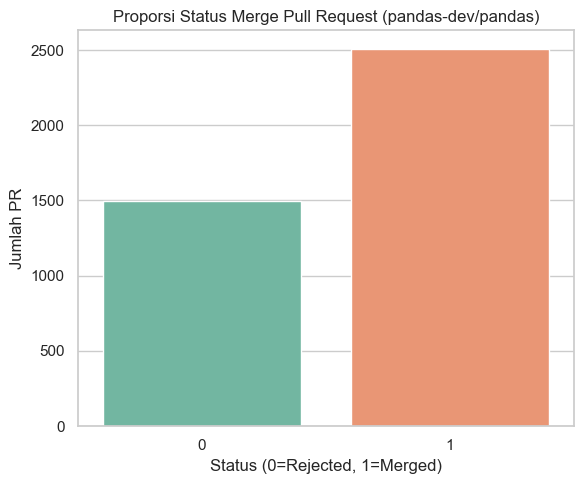

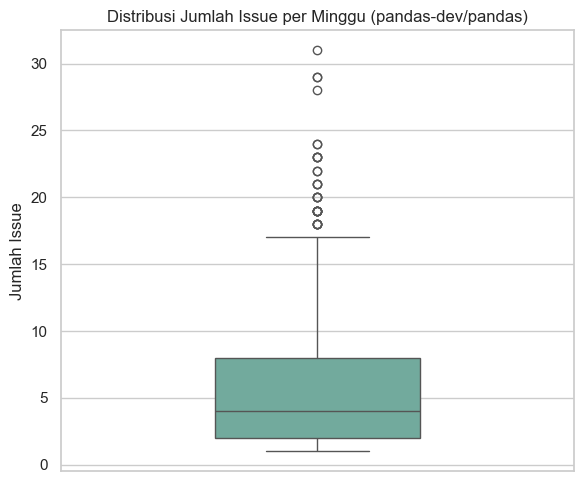

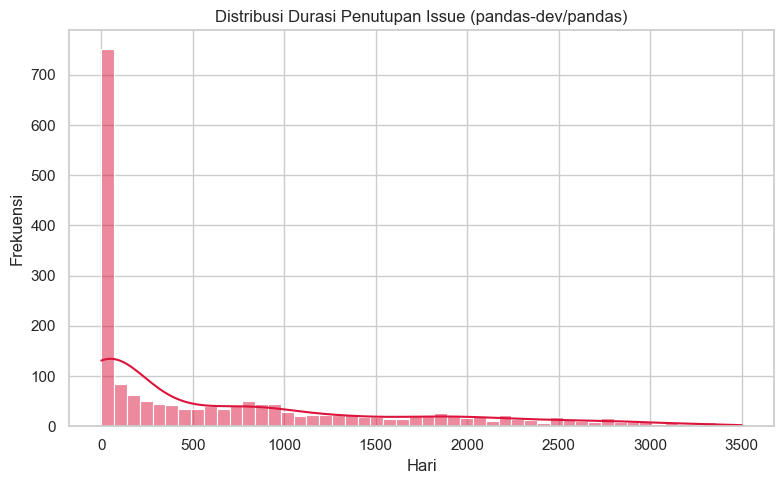

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/clean/dataset.csv")

# Filter
df_pr = df[df['type'] == 'pull_request'].copy()
df_issue = df[df['type'] == 'issue'].copy()
df_issue_clean = df_issue[df_issue['duration_days'] >= 0].copy()

# Q1: Bar chart PR merged vs rejected
plt.figure(figsize=(6, 5))
sns.countplot(data=df_pr, x='is_merged', hue='is_merged', palette='Set2', legend=False)
plt.title('Proporsi Status Merge Pull Request (pandas-dev/pandas)')
plt.xlabel('Status (0=Rejected, 1=Merged)')
plt.ylabel('Jumlah PR')
plt.tight_layout()
plt.show()

# Q2: Boxplot distribusi issue per minggu
df_issue['created_at'] = pd.to_datetime(df_issue['created_at'])
weekly_count = df_issue.groupby(df_issue['created_at'].dt.to_period('W')).size()
plt.figure(figsize=(6, 5))
sns.boxplot(y=weekly_count, color='#69b3a2', width=0.4)
plt.title('Distribusi Jumlah Issue per Minggu (pandas-dev/pandas)')
plt.ylabel('Jumlah Issue')
plt.tight_layout()
plt.show()

# Q3: Histogram durasi penutupan issue
plt.figure(figsize=(8, 5))
sns.histplot(data=df_issue_clean, x='duration_days', bins=50, kde=True, color='crimson')
plt.title('Distribusi Durasi Penutupan Issue (pandas-dev/pandas)')
plt.xlabel('Hari')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Analisis

Jika dilihat dari grafik yang sudah dibuat, dapat disimpulkan beberapa hal berikut:
* Jika, dilihat dari grafik yang sudah dibuat. Dapat dilihat bahwa grafik pada bagian merged PR terlihat lebih banyak atau lebih tinggi dibandingkan PR rejected/closed yang dimana PR merged berada pada angka 2.500. Selanjutnya, probabilitas merged memiliki cenderung tinggi dibandingkan PR rejected/close, lalu data hanya diambil dari tahun atau periode tertentu saja.
~ Jika dilihat dari hasil boxplot pada RQ2, distribusi jumlah issue yang masuk per minggu, nilai median pada kedatangan issue berada pada angka yang relatif lebih rendah dan stabil, yaitu sekitar  3 issue per minggu. Setengah dari total data mingguan juga berkumpul secara konsisten di rentang bawah ada diantara 2-7 issue. Banyak titik yang melesat tinggi ke atas, yang membentang dari angka 15 hingga menembus 30 issue, lonjakan tersebut mengindikasikan adanya minggu-minggu tertentu dengan aktivitas issue yang di atas nomal, yang kemungkinan bisa berkaitan dengan periode setelah major release.
~ Jika dilihat dari hasil histogram pada RQ3, distribusi penutupan issue pada repositori menunjukkan pola right skewed yang ekstrem. Frekuensi paling tinggi ada pada rentang awal, yang dimana itu menandakan bahwa sebagian besar issue berhasil di selesaikan dalam waktu singkat. Tetapi, terdapat ekor panjang ke kanan yang melebihi dari 4000 hari, itu menunjukkan sebagian kecil issue membutuhkan waktu yang sangat lama untuk ditutup.